## 실행 환경: 구글 코랩

---
### 기본 설정 & 한글 폰트 (Colab)



In [43]:
!apt -qq -y install fonts-nanum > /dev/null

In [44]:
import os, shutil, re
from io import StringIO

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.feature_selection import SelectFromModel

from imblearn.over_sampling import SMOTE

import joblib

In [45]:
shutil.rmtree(os.path.expanduser("~/.cache/matplotlib"), ignore_errors=True) # 한글 폰트 설정
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
mpl.rc("font", family="NanumGothic")
mpl.rcParams["axes.unicode_minus"] = False
sns.set_theme(rc={"font.family": "NanumGothic", "axes.unicode_minus": False})

---
# 📌 1. Winsorization 함수 정의
- 이상치를 제거/삭제하지 않고 일부 범위로 "압축"하는 함수 정의

- (1%, 99%) 분위수 기준으로 clip 수행

In [46]:
def winsor_fit(X, lower=0.01, upper=0.99):
    X = np.asarray(X, dtype=float)              #float변환 (계산 안전성 확보)
    q_low = np.quantile(X, lower, axis=0)
    q_high = np.quantile(X, upper, axis=0)
    return q_low, q_high

def winsor_transform(X, q_low, q_high):
    X = np.asarray(X, dtype=float)
    X_w = np.clip(X, q_low, q_high)             # 이상치를 압축
    return X_w

---
# 📌 2. 데이터 로드 + Train/Validation Split + 0→NaN 처리

- CSV 로드

- 타겟 분리

- Stratified Split

- 0값이 60% 이상인 컬럼을 결측치(NaN)로 교체


# (1) Stratified Split으로 클래스 비율 유지

In [47]:
TARGET_COL = "Bankrupt?" # 타겟 지정

 # 데이터 불러오기 및 컬럼명 공백 제거
df = pd.read_csv("classification_train_public.csv")
df.columns = df.columns.str.strip()

# 특징(X)과 타겟(y) 분리
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]


# 학습/검증 데이터 분리 (8:2 비율, 클래스 비율 유지)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train: {X_train.shape}, val: {X_val.shape}")

train: (4091, 95), val: (1023, 95)


# (2) 0이 너무 많은 컬럼 → 0을 결측치로 간주
(이후 Imputer에서 처리)



In [48]:
# 학습 데이터에서 0 비율 계산 후 정렬
zero_ratio = (X_train == 0).mean().sort_values(ascending=False)

# 0 비율이 60% 이상이면 '의심 컬럼'으로 간주
SUSPECT_THRESH = 0.60
suspect_cols = zero_ratio[zero_ratio >= SUSPECT_THRESH].index.tolist()

# 학습/검증 데이터 복사본 생성
X_train_processed = X_train.copy()
X_val_processed = X_val.copy()

# 의심 컬럼의 0값을 NaN으로 변환
for c in suspect_cols:
    X_train_processed[c] = X_train_processed[c].replace(0, np.nan)
    X_val_processed[c] = X_val_processed[c].replace(0, np.nan)

print(f" 0->NaN 처리 대상 컬럼 수: {len(suspect_cols)}")
print(f"컬럼명: {suspect_cols}")


 0->NaN 처리 대상 컬럼 수: 1
컬럼명: ['Liability-Assets Flag']


---
# 📌 3. 개별 전처리 + SMOTE + 기본 모델 비교
- 전처리를 단계적으로 직접 수행하여 Tree 기반 모델 4개 성능 비교
- 데이터 누수를 막고, 모델 학습 효율을 최대로 높이기 위해

### 모델 정의

In [49]:
models = {
    "DT": DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_leaf=5),
    "RF": RandomForestClassifier(random_state=42, n_estimators=200, max_depth=15,
                                 min_samples_leaf=3, n_jobs=-1),
    "ET": ExtraTreesClassifier(random_state=42, n_estimators=200, max_depth=15,
                               min_samples_leaf=5, n_jobs=-1),
    "GB": GradientBoostingClassifier(random_state=42, n_estimators=150,
                                     learning_rate=0.1, max_depth=3),
}

print("--- 3단계: 개별 전처리 + SMOTE + 기본 모델 학습 시작 ---")


--- 3단계: 개별 전처리 + SMOTE + 기본 모델 학습 시작 ---


# (1) Imputer — 결측치를 중앙값으로 채움

👉 이유
- 이상치 찾을 때 NaN이 있으면 계산 불가

- 스케일링도 NaN 처리 못함

- SMOTE는 결측치가 있는 데이터를 절대 처리 못함

In [50]:
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_processed) # 학습 데이터에 fit + transform 수행
X_val_imp   = imputer.transform(X_val_processed) # 검증 데이터 transform만 수행

X_train_imp_df = pd.DataFrame(X_train_imp, columns=X_train_processed.columns)

### impute 결과 전/후 비교

In [51]:
print("[Imputer 적용 전 결측치 개수]")
print(X_train_processed.isna().sum().tail(15))

print("[Imputer 적용 후 결측치 개수]")
print(X_train_imp_df.isna().sum().tail(15))

print("[Imputer 적용 전/후 특정 컬럼 통계 비교]")
col = "Liability-Assets Flag"
print("▶ Before")
print(X_train_processed[col].describe())
print("\n▶ After (Imputed)")
print(X_train_imp_df[col].describe())

[Imputer 적용 전 결측치 개수]
Cash Flow to Liability                                   0
CFO to Assets                                            0
Cash Flow to Equity                                      0
Current Liability to Current Assets                      0
Liability-Assets Flag                                 4087
Net Income to Total Assets                               0
Total assets to GNP price                                0
No-credit Interval                                       0
Gross Profit to Sales                                    0
Net Income to Stockholder's Equity                       0
Liability to Equity                                      0
Degree of Financial Leverage (DFL)                       0
Interest Coverage Ratio (Interest expense to EBIT)       0
Net Income Flag                                          0
Equity to Liability                                      0
dtype: int64
[Imputer 적용 후 결측치 개수]
Cash Flow to Liability                                0
CF

--Before에서 count=4의 뜻은 원본 X_train_processed에서
이 컬럼 값의 NaN이 아닌 값이 4개밖에 없었다는 뜻
즉, 대부분이 NaN(또는 0 -> NaN 변환된 값)이었음

--Imputer는 NaN 값을 해당 컬럼의 median(=1.0) 으로 채움.
그래서 기존 NaN들이 모두 1.0 로 바뀜.

즉, 전체 4091개 모두 값이 생겼기 때문에 count=4091이 뜬 것.

# (2) Winsorization — 이상치를 1%~99% 범위로 압축
👉 이유

- 이상치(Outlier) 처리는 데이터 분포를 안정화시키기 위함인데, 결측치가 있으면 왜곡.

- SMOTE는 데이터 분포 기반으로 synthetic sample 생성 → 이상치가 포함되면 이상한 synthetic 데이터 증가.

- Scaler보다 먼저 해야 정상 스케일링 가능.


In [52]:
q_low, q_high = winsor_fit(X_train_imp, lower=0.01, upper=0.99)
X_train_win = winsor_transform(X_train_imp, q_low, q_high)
X_val_win   = winsor_transform(X_val_imp,  q_low, q_high)

X_train_win_df = pd.DataFrame(X_train_win, columns=X_train_processed.columns)

훈련 데이터 기준으로 1%/99% 분위수를 구해서
그 밖의 값들을 분위수 값으로 잘라냈고,
Winsorization 전후로 min, max, quantile(0.01, 0.99)를 비교해서
극단값이 적절히 잘린 걸 확인

### Winsorization 결과 확인

In [53]:
col = "Borrowing dependency"
print("[Winsorization 적용 전/후 최소·최대값 비교]")
print("▶ Before (Imputed):", X_train_imp_df[col].min(), X_train_imp_df[col].max())
print("▶ After  (Winsor):", X_train_win_df[col].min(), X_train_win_df[col].max())

print("\n[해당 변수 분위수 비교]")
print("Before:")
print(X_train_imp_df[col].quantile([0.01, 0.5, 0.99]))
print("\nAfter:")
print(X_train_win_df[col].quantile([0.01, 0.5, 0.99]))

[Winsorization 적용 전/후 최소·최대값 비교]
▶ Before (Imputed): 0.187124091052444 0.887434771619588
▶ After  (Winsor): 0.36963718146295 0.40005312212721106

[해당 변수 분위수 비교]
Before:
0.01    0.369637
0.50    0.372695
0.99    0.400053
Name: Borrowing dependency, dtype: float64

After:
0.01    0.369637
0.50    0.372695
0.99    0.399987
Name: Borrowing dependency, dtype: float64


극단값(outlier) 억제를 위해 Winsorization(0.01-0.99 구간)을 적용
이 변수는 중간 분위수에는 값이 몰려 있었지만,
최소·최대값이 원래 0.18~0.88로 매우 넓게 퍼져 있어 모델에 영향을 줄 수 있음
Winsorization 결과 최소값과 최대값이 각각 0.369-0.400 구간으로 안정적으로 클리핑되었고,
이후 스케일링 과정에서 모델의 안정성 향상에 도움이 됨.

# (3) StandardScaler — 평균 0, 표준편차 1로 정규화
👉이유
- Winsorization에서 값이 변한 다음, 그 값까지 포함해서 스케일을 맞춰야 하기 때문.

- 만약 Scaler 먼저 → Winsorization 후 다시 값이 튀어서 스케일이 깨짐.


In [54]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_win) # 학습 데이터에 fit + transform 수행
X_val_scaled   = scaler.transform(X_val_win) # 검증 데이터는 transform만 수행

Winsorization까지 적용한 뒤 StandardScaler로 각 변수를 평균 0, 표준편차 1이 되도록 변환했고,
몇 개 핵심 변수에 대해 describe()로 mean≈0, std≈1인지 확인했습니다.

### StandardScaler 결과 확인

In [55]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_processed.columns)
print("[StandardScaler 적용 후 요약 통계]")
print(X_train_scaled_df[["Liability-Assets Flag",
                         "Net Income to Stockholder's Equity"]].describe())

[StandardScaler 적용 후 요약 통계]
       Liability-Assets Flag  Net Income to Stockholder's Equity
count                 4091.0                        4.091000e+03
mean                     0.0                        1.017486e-14
std                      0.0                        1.000122e+00
min                      0.0                       -4.806895e+00
25%                      0.0                       -2.385377e-01
50%                      0.0                        1.239166e-01
75%                      0.0                        5.374977e-01
max                      0.0                        1.950021e+00


StandardScaler를 적용한 결과,
Net Income to Stockholder's Equity 변수는 평균이 0에 매우 가깝고
표준편차가 1에 가까운 표준화된 형태가 되었으며,
값의 범위는 약 -4.8 ~ 1.95로, 평균 기준으로 일부 음의 방향으로 큰 편차를 갖는 관측치가 존재함을 확인

# (4) SMOTE — 클래스 불균형 개선
- 소수 클래스 샘플들 사이에서 새로운 가짜 샘플을 생성해서
조금 더 부드럽게 데이터 분포를 확대하는 오버샘플링 기법.

- sampling_strategy=0.3으로 설정해서
'부실 기업 : 정상 기업' 비율을 약 3:7 정도로 맞춤.

In [56]:
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train) # 학습 데이터에 SMOTE 적용

### SMOTE 결과 확인

In [57]:
print("[SMOTE 적용 전 클래스 분포]")
print(y_train.value_counts(normalize=True))

print("\n[SMOTE 적용 후 클래스 분포]")
print(y_train_res.value_counts(normalize=True))

[SMOTE 적용 전 클래스 분포]
Bankrupt?
0    0.967734
1    0.032266
Name: proportion, dtype: float64

[SMOTE 적용 후 클래스 분포]
Bankrupt?
0    0.769335
1    0.230665
Name: proportion, dtype: float64


**SMOTE 적용 전 -> 극단적인 불균형 데이터**

부실기업이 전체의 3%밖에 안 됨.
모델이 "전부 정상"이라고만 예측해도

Accuracy > 0.95 나옴

RECALL(부실기업 탐지율)이 매우 낮아지는 문제가 발생

즉, 학습이 제대로 안 되고, 부실기업을 거의 못 잡는 모델이 생김


**SMOTE 적용 후 ->
정상/부실 비율이 약 3:1 수준으로 조정됨.**

우리가 SMOTE 파라미터를 sampling_strategy=0.3으로 했기 때문에

부실기업의 비율을 정상 대비 약 30% 수준으로 올린 것.

즉:

before: 3% /
after : 23%

불균형 문제 대부분 해소됨

# (5) 기본 모델 비교

- DT / RF / ET / GB 학습 및 예측

- M-Score = (Accuracy + Recall + Precision) / 3

왜 모델을 복사해서 쓰나

    ➡️ 모델 상태 오염 방지
    ➡️ 반복문에서 독립적인 학습 보장
    ➡️ scikit-learn은 fit 후 내부 파라미터가 생기기 때문에 반드시 새 객체 필요

predict는 뭐가 달라지는가?

    ➡️ fit() 이후 저장된 모델 구조로
    ➡️ validation 데이터에 대해 예측
    ➡️ 0/1 라벨 반환

In [58]:
results = []

# 모델 반복 학습 및 평가
# clf.fit()은 '각 모델을 공정하게 같은 데이터로 학습시키는 것'
for name, base_clf in models.items():
    clf = base_clf.__class__(**base_clf.get_params()) # 모델 복사 (기존 객체 영향 방지)
    clf.fit(X_train_res, y_train_res)  # SMOTE 적용 학습 데이터로 학습

    # 검증 데이터 예측
    #이건 검증(validation) 단계
    # X_val_scaled는 validation 데이터
    # 여기에는 SMOTE 절대 적용 안 됨
    # 오직 “스케일링까지 동일한 전처리만 적용된 원본 검증 데이터”
    # predict 함수는 "확률이 아니라 0/1 라벨"을 반환
    # 내부적으로 기준(threshold) 0.5 사용
    # 랜덤포레스트 등은 투표 기반
    y_pred = clf.predict(X_val_scaled)
    # 성능 지표 계산
    acc  = accuracy_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    prec = precision_score(y_val, y_pred, zero_division=0)
    m    = (acc + rec + prec) / 3.0

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Recall": rec,
        "Precision": prec,
        "M_Score": m,
    })

    print(f"[{name}] M-Score: {m:.4f}")

[DT] M-Score: 0.4959
[RF] M-Score: 0.6267
[ET] M-Score: 0.6711
[GB] M-Score: 0.6310


# 1차: 결과 정리 + 잠정 최적 모델 선정

In [59]:
results_df = pd.DataFrame(results).sort_values(by="M_Score", ascending=False)
print("--- 1차 기본 모델 성능 비교 ---")
print(results_df.round(4))

best_model_name_initial = results_df.iloc[0]["Model"]
print(f"\n 1차 잠정 최적 모델: {best_model_name_initial}")


--- 1차 기본 모델 성능 비교 ---
  Model  Accuracy  Recall  Precision  M_Score
2    ET    0.9629  0.6061     0.4444   0.6711
3    GB    0.9638  0.4848     0.4444   0.6310
1    RF    0.9629  0.4848     0.4324   0.6267
0    DT    0.9306  0.3636     0.1935   0.4959

 1차 잠정 최적 모델: ET


---
# 📌 4. 하이퍼파라미터 튜닝 (ET, RF, GB)

- 1차 모델 후보 중 성능 좋은 모델의 파라미터 최적화
   - ET, RF에는 GridSearchCV
   - GB에는 RandomizedSearchCV



In [60]:
print("--- 4단계: 하이퍼파라미터 튜닝 시작 ---")

tuned_models = {
    "ET": {
        "model": ExtraTreesClassifier(random_state=42, n_jobs=-1),
        "searcher": GridSearchCV,
        "grid": {
            "n_estimators": [200, 300, 400],
            "max_depth": [15, 20, 25, 30],
            "min_samples_leaf": [3, 5, 8],
        },
    },
    "RF": {
        "model": RandomForestClassifier(random_state=42, n_jobs=-1),
        "searcher": GridSearchCV,
        "grid": {
            "n_estimators": [200, 300, 400],
            "max_depth": [15, 20, 25, 30],
            "min_samples_leaf": [3, 5, 8],
        },
    },
    "GB": {
        "model": GradientBoostingClassifier(random_state=42),
        "searcher": RandomizedSearchCV,
        "grid": {
            "n_estimators": [100, 150, 200],
            "learning_rate": [0.05, 0.1, 0.15],
            "max_depth": [3, 4, 5],
            "min_samples_leaf": [3, 5],
        },
        "n_iter": 10, # RandomizedSearchCV 반복 횟수
    },
}

--- 4단계: 하이퍼파라미터 튜닝 시작 ---


**"하이퍼파라미터 튜닝 과정에서 최고의 모델을 찾기 위해
초기 변수들을 선언하는 구문"**

In [61]:
# tuned_results=[] <- 각 모델의 튜닝 결과(성능, best_params등)를
# 리스트 형태로 저장하기 위한 공간 (튜닝 결과 요약표를 만드는 저장소)
tuned_results = []

**best_m_score_global=-1**

"전체 모델 중 가장 높은 M-Score를 기록하기 위한 초기값"

    ❓ 왜 -1?

    M-Score는 보통 0~1 사이인데,
    처음 비교할 때 모든 모델이 이 값보다 크도록(=무조건 갱신되도록) 하려고 -1로 설정함.

In [62]:
# "현재까지 최고 모델 점수는 -1점이다."
# 첫번째 모델 점수는 당연히 -1보다 크므로 갱신됨
# 최고 성능 모델을 갱신하는 기준값
best_m_score_global = -1 # 전체 모델 중 최고 M_Score 초기화

# 아직 최고 점수 모델이 정해지지 않았다는 뜻임
# 지금까지 가장 잘 나온 모델의 이름을 보관하는 저장소
best_model_name = None

# 가장 성능이 좋은 best estimator(모델 객체)를 저장할 변수
# 튜닝 과정에서 best_clf=best_est 같이 최적 모델 객체를 저장해둠
# 저장되는 객체 (예: 튜닝된 ExtraTreesClassifier, GridSearchCV로 정해진 RandomForestClassifier, RandomizedSearchCV로 정해진 GradientBoostingClassifier)
# 즉, 튜닝 종료 후 바로 사용 가능한 최종 모델이 여기에 담김.
best_clf = None

- tuned_results :	모든 모델 튜닝 결과 저장 리스트
- best_m_score_global = -1 : 최고 성능 기록용 기준 점수
- best_model_name = None : 최고 모델 이름 저장
- best_clf = None : 최고 모델 객체 저장

- **최종 결과**
- best_m_score_global = 0.74
- best_model_name = "RF"
- best_clf = (튜닝된 RF 모델 객체)

## for문을 사용하는 이유
- ET, RF, GB 세가지 모델을 각각 따로 튜닝해야함

1.   모델 준비
2.   SearchCV 준비
3.   param grid 넣기
4.   fit -> best_estimator_ 꺼내기
5.   성능 계산

-  for문으로 묶으면 코드가 1/3으로 줄어들어 깔끔해짐


## item이 필요한 이유

tuned_models 딕셔너리에서 각 모델에대한 설정묶음을
-  model = item["model"]
-  Searcher = item["searcher"]
-  param_grid = item["grid"]
이렇게 꺼내기 위해선 item이 필요

** item이 없다면 모델 설정을 개별 변수로 하나하나 관리하게 된다.

-> 코드 길이 3배 증가의 단점 존재

=> item으로 딕셔너리 묶음을 한번에 처리해줌

In [63]:
# 튜닝 모델들을 한 번에 묶어서 자동으로 돌리기 위한 핵심 구조
# 모델별 하이퍼파라미터 튜닝 반복
for name, item in tuned_models.items():
    model = item["model"]                  # 기본 모델
    Searcher = item["searcher"]            # GridSearchCV 또는 RandomizedSearchCV
    param_grid = item["grid"]              # 하이퍼파라미터 범위

    if Searcher == RandomizedSearchCV:
        search = Searcher(
            estimator=model,
            param_distributions=param_grid,
            n_iter=item.get("n_iter", 10),  # 탐색 횟수
            scoring="f1",                   # 평가 지표
            cv=3,                           # 교차검증 fold 수
            n_jobs=-1,                      # 병렬 처리
            verbose=0,                      # 출력 메세지 레벨
            random_state=42,
        )
    else:
        search = Searcher(
            estimator=model,
            param_grid=param_grid,
            scoring="f1",
            cv=3,
            n_jobs=-1,
            verbose=0,
        )

## verbose: 출력 메세지 레벨
-  0: 아무 출력 x
-  1: 진행상황 간단히 보여줌
-  2: 매우 상세한 로그 출력

**지금 코드에 verbose=0을 준 이유:**

GridSearchCV / RandomizedSearchCV는 파라미터 조합이 많을수록 출력 메시지가 엄청 많음

Colab 환경에서는 출력이 길면 불편하고 시간도 더 걸림

그래서 불필요한 로그를 끄기 위해 verbose=0을 사용함.

##전체 요약
🔹 왜 for문?

ET, RF, GB 모델을 똑같은 방식으로 튜닝해야 하기 때문에

한 번에 자동 반복하려고 사용

코드 반복 제거 + 유지보수 쉬움

🔹 왜 item?

각 모델의 구성 요소(모델, SearchCV 종류, 파라미터 grid)를
딕셔너리로 묶어서 하나씩 꺼내 쓰기 위해

🔹 verbose란?

출력 로그 상세 정도

0은 “조용”,

1은 “조금 말해”,

2는 “많이 말해”

In [33]:
    search.fit(X_train_res, y_train_res) # SMOTE 적용 학습 데이터 사용, 재전처리 불필요
    best_est = search.best_estimator_
    y_pred = best_est.predict(X_val_scaled)

    # 성능 지표 계산
    acc  = accuracy_score(y_val, y_pred)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    prec = precision_score(y_val, y_pred, zero_division=0)
    m    = (acc + rec + prec) / 3.0

    tuned_results.append({
        "Model": name,
        "Searcher": "Grid" if Searcher == GridSearchCV else "Randomized",
        "Accuracy": acc,
        "Recall": rec,
        "Precision": prec,
        "M_Score": m,
        "Best_Params": search.best_params_,
    })

    print(f"[튜닝 완료] {name} / M-Score: {m:.4f}")

    if m > best_m_score_global:
        best_m_score_global = m
        best_model_name = name
        best_clf = best_est

[튜닝 완료] GB / M-Score: 0.6408


# 최종 모델 선택

In [34]:
tuned_df = pd.DataFrame(tuned_results).sort_values(by="M_Score", ascending=False)
print("\n--- 2차 튜닝 결과 (M-Score 기준 정렬) ---")
print(tuned_df[["Model", "Searcher", "Accuracy", "Recall", "Precision", "M_Score"]].round(4))

print(f"\n최종 선택된 모델: {best_model_name}")
print("최종 Best Params:")
print(tuned_df[tuned_df["Model"] == best_model_name]["Best_Params"].iloc[0])

final_best_classifier = best_clf
base_clf_class = final_best_classifier.__class__
base_clf_params = final_best_classifier.get_params()



--- 2차 튜닝 결과 (M-Score 기준 정렬) ---
  Model    Searcher  Accuracy  Recall  Precision  M_Score
0    GB  Randomized    0.9677  0.4545        0.5   0.6408

최종 선택된 모델: GB
최종 Best Params:
{'n_estimators': 150, 'min_samples_leaf': 3, 'max_depth': 5, 'learning_rate': 0.15}


---
# 📌 5. Feature Importance 기반 변수 선택(Top 70)
- Final best model의 feature_importances_ 사용

- 상위 70개 변수 선정


In [35]:
print("\n--- 5단계: Feature Importance 기반 변수 선택 ---")

# 최종 모델은 DT/RF/ET/GB 중 하나이므로 feature_importances_가 항상 존재한다고 가정
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_best_classifier.feature_importances_,
}).sort_values(by="Importance", ascending=False)

selected_features = importance_df.head(70)["Feature"].tolist()

print(f"중요도 Top70 변수 선택 -> 70개 중 head 10개만 출력")
print(importance_df.head(10).to_string(index=False, float_format="%.4f"))


--- 5단계: Feature Importance 기반 변수 선택 ---
중요도 Top70 변수 선택 -> 70개 중 head 10개만 출력
                                           Feature  Importance
                Net Income to Stockholder's Equity      0.1919
                              Borrowing dependency      0.1899
           Persistent EPS in the Last Four Seasons      0.0589
                        Total debt/Total net worth      0.0441
              Continuous interest rate (after tax)      0.0357
       Non-industry income and expenditure/revenue      0.0342
             Research and development expense rate      0.0297
                Degree of Financial Leverage (DFL)      0.0246
Interest Coverage Ratio (Interest expense to EBIT)      0.0236
                  Contingent liabilities/Net worth      0.0210


# Top 10 변수 중요도 시각화

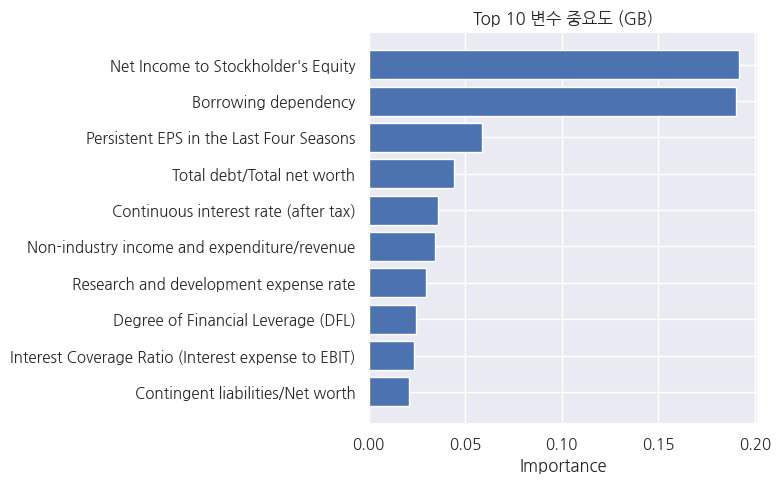

In [36]:
top10 = importance_df.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title(f"Top 10 변수 중요도 ({best_model_name})")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

---
# 📌 6. 변수 선택 모델(SelectFromModel) + Validation 평가

# (1) 70개 선택된 변수들을 기반으로: Imputer → Winsorization → Scaler


In [37]:
print("\n--- 6단계: 최종 모델(Validation) 분석 및 시각화 ---")

# (1) Top_K 변수만 사용
X_train_sel = X_train_processed[selected_features]
X_val_sel   = X_val_processed[selected_features]

# (2) 결측치 처리: 중앙값(Imputer)
imputer_fs = SimpleImputer(strategy="median")
X_train_imp_fs = imputer_fs.fit_transform(X_train_sel)
X_val_imp_fs   = imputer_fs.transform(X_val_sel)

# (3) Winsorization
q_low_fs, q_high_fs = winsor_fit(X_train_imp_fs, lower=0.01, upper=0.99)
X_train_win_fs = winsor_transform(X_train_imp_fs, q_low_fs, q_high_fs)
X_val_win_fs   = winsor_transform(X_val_imp_fs,  q_low_fs, q_high_fs)

# (4) StandardScaler
scaler_fs = StandardScaler()
X_train_scaled_fs = scaler_fs.fit_transform(X_train_win_fs)
X_val_scaled_fs   = scaler_fs.transform(X_val_win_fs)


--- 6단계: 최종 모델(Validation) 분석 및 시각화 ---


#(2) 2차 변수 선택: SelectFromModel(threshold='median')

**“왜 SelectFromModel을 Top_K 다음에 또 하나요?”**

- Top_K는 ‘단순 중요도 높은 순서 자르기’
- SelectFromModel은 ‘모델이 스스로 최선의 조합을 고르게 함’

→ 차원 축소 + 과적합 방지 + 변수 중복 제거 효과

In [38]:
# (5) 2차 변수 선택: SelectFromModel
selector = SelectFromModel(
    base_clf_class(**base_clf_params),   # 최종 선정된 모델 (GB)
    threshold="median"                   # 중요도 중앙값 이상만 선택
)
selector.fit(X_train_scaled_fs, y_train) # 학습 수행
# 표준화된 데이터를 모델에 넣고 각 변수의 중요도를 계산

# 선택된 변수 리스트
selected_after_fs = [
    col for col, keep in zip(selected_features, selector.get_support()) if keep
]

# transform 적용
X_train_final = selector.transform(X_train_scaled_fs)
X_val_final   = selector.transform(X_val_scaled_fs)

print(f"최종 선택된 변수 개수: {len(selected_after_fs)}")

최종 선택된 변수 개수: 35


#(3) 최종 모델로 Validation 평가



In [ ]:
# (6) 최종 검증용 모델 학습 (SMOTE 없이, 원본 분포 기준)
final_clf_val = base_clf_class(**base_clf_params)
final_clf_val.fit(X_train_final, y_train)

# 항상 predict_proba 사용 + threshold=0.5
y_val_proba = final_clf_val.predict_proba(X_val_final)[:, 1]
y_val_pred  = (y_val_proba >= 0.5).astype(int)

print("\n[Validation 성능 (최종 변수 선택 후)]")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred, zero_division=0))
print("Precision:", precision_score(y_val, y_val_pred, zero_division=0))
print("\nClassification Report:\n",
      classification_report(y_val, y_val_pred, target_names=["정상", "부실"]))


# (4) Confusion Matrix 시각화

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "부실(1)"]).plot(values_format="d")
plt.title("검증용 혼동행렬 (Validation)")
plt.tight_layout()
plt.show()

# (5) PR Curve 시각화

In [ ]:
# PR Curve
y_val_proba = final_clf_val.predict_proba(X_val_final)[:, 1]

prec_arr, rec_arr, _ = precision_recall_curve(y_val, y_val_proba)
avg_prec = average_precision_score(y_val, y_val_proba)
baseline = y_val.mean()  # 양성 비율

plt.figure(figsize=(6, 5))
plt.plot(rec_arr, prec_arr, lw=2, label=f"PR Curve (AP = {avg_prec:.4f})")
plt.axhline(baseline, linestyle="--", lw=1,
            label=f"Baseline (부실 비율 = {baseline:.4f})")
plt.xlabel("Recall (재현율)")
plt.ylabel("Precision (정밀도)")
plt.title("Precision–Recall Curve (Validation)")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()

---
# 📌 7. 전체 Train + Private Test로 최종 학습 및 제출 파일 생성

### 전체 train 데이터 + private test 데이터에 동일 적용:

- Train 전체 로드

- 0→NaN 변환

- Top_K 변수만 사용

- 전처리(Imputer → Winsor → StandardScaler)

- SelectFromModel

- 모델 재학습

- 제출 파일 생성

- model.pkl 저장

In [ ]:
print("\n=== 7단계: 최종 제출용 전체 데이터 재학습 및 제출 파일 생성 ===")

# (1) train 전체 데이터 준비
X_all = df.drop(columns=[TARGET_COL])
y_all = df[TARGET_COL]

X_all_processed = X_all.copy()
for c in suspect_cols:
    X_all_processed[c] = X_all_processed[c].replace(0, np.nan)

# (2) private test 로드 + 동일 전처리
test_path = "classification_test_private.csv"
test_df = pd.read_csv(test_path)
test_df.columns = test_df.columns.str.strip()
X_test_all = test_df.copy()

for c in suspect_cols:
    if c in X_test_all.columns:
        X_test_all[c] = X_test_all[c].replace(0, np.nan)

print(" - train 전체 shape :", X_all_processed.shape)
print(" - test  전체 shape :", X_test_all.shape)

# (3) Top_K 변수만 사용
X_all_sel  = X_all_processed[selected_features]
X_test_sel = X_test_all[selected_features]

print(" - Top_K(70개) 변수 사용 후 train shape :", X_all_sel.shape)
print(" - Top_K(70개) 변수 사용 후 test  shape :", X_test_sel.shape)

# (4) 전처리: Imputer → Winsorization → Scaler
final_imputer = SimpleImputer(strategy="median")
X_all_imp  = final_imputer.fit_transform(X_all_sel)
X_test_imp = final_imputer.transform(X_test_sel)

q_low_final, q_high_final = winsor_fit(X_all_imp, lower=0.01, upper=0.99)
X_all_win  = winsor_transform(X_all_imp,  q_low_final, q_high_final)
X_test_win = winsor_transform(X_test_imp, q_low_final, q_high_final)

final_scaler = StandardScaler()
X_all_scaled  = final_scaler.fit_transform(X_all_win)
X_test_scaled = final_scaler.transform(X_test_win)

print(" - 전처리 후 train shape :", X_all_scaled.shape)
print(" - 전처리 후 test  shape :", X_test_scaled.shape)

# (5) 2차 변수 선택: SelectFromModel
final_feature_selector = SelectFromModel(
    base_clf_class(**base_clf_params),
    threshold="median",
    prefit=False
)
final_feature_selector.fit(X_all_scaled, y_all)

mask_full = final_feature_selector.get_support()
if mask_full.sum() == 0:
    print("[WARN] 최종 SelectFromModel에서 선택된 변수가 없어 Top_K만 사용합니다.")
    X_all_final  = X_all_scaled
    X_test_final = X_test_scaled
    selected_after_fs_full = selected_features.copy()
else:
    X_all_final  = final_feature_selector.transform(X_all_scaled)
    X_test_final = final_feature_selector.transform(X_test_scaled)
    selected_after_fs_full = np.array(selected_features)[mask_full].tolist()

print(f"\n[최종 변수 선택] SelectFromModel 적용 후 최종 변수 개수: {len(selected_after_fs_full)}")
print(" - 최종 train shape :", X_all_final.shape)
print(" - 최종 test  shape :", X_test_final.shape)

# (6) Simplified Name 매핑
md_path = "classification_description_v2.md"
with open(md_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Markdown 테이블 파싱 후 CSV 형식으로 변환
table_lines = []
in_table = False
for line in lines:
    if "|" in line and ("Original Variable" in line or in_table):
        in_table = True
        table_lines.append(line)
    elif in_table and ("|" not in line or line.strip() == ""):
        break

table_clean = [
    line for line in table_lines
    if not re.match(r"^\s*\|?\s*-[-\s]*\|", line)
]

table_str = "".join(table_clean)
desc = pd.read_csv(StringIO(table_str), sep="|").dropna(axis=1, how="all")

desc.columns = desc.columns.str.strip()
desc = desc.applymap(lambda x: x.strip() if isinstance(x, str) else x)

mapping_table = desc[["Original Variable (CSV Header)", "Simplified Name"]]
origin_to_simple = dict(zip(mapping_table["Original Variable (CSV Header)"],
                            mapping_table["Simplified Name"]))

final_feature_names = [origin_to_simple[col.strip()] for col in selected_after_fs_full]
print("\n[INFO] 최종 Simplified Name 목록:")
print(final_feature_names)
print("개수:", len(final_feature_names))

# (7) 최종 모델 학습 (train 전체 + 2차 변수 선택)
final_model = base_clf_class(**base_clf_params)
final_model.fit(X_all_final, y_all)

# threshold=0.5 기준 예측
if hasattr(final_model, "predict_proba"):
    y_train_proba_full = final_model.predict_proba(X_all_final)[:, 1]
    y_pred_train_full  = (y_train_proba_full >= 0.5).astype(int)

    y_test_proba_full = final_model.predict_proba(X_test_final)[:, 1]
    y_pred_test_full  = (y_test_proba_full >= 0.5).astype(int)
else:
    y_pred_train_full = final_model.predict(X_all_final)
    y_pred_test_full  = final_model.predict(X_test_final)

print("\n--- [최종 모델 - train 전체에 대한 성능(참고용)] ---")
print("Train Accuracy :", accuracy_score(y_all, y_pred_train_full))
print("Train Recall   :", recall_score(y_all, y_pred_train_full, zero_division=0))
print("Train Precision:", precision_score(y_all, y_pred_train_full, zero_division=0))

# (8) submission_train.csv 생성
train_features_df = pd.DataFrame(
    X_all_final,
    columns=final_feature_names,
    index=X_all.index
)
submission_train = train_features_df.copy()
submission_train["y_true"] = y_all.values
submission_train["y_pred"] = y_pred_train_full

submission_train.to_csv("submission_train.csv", index=False)
print("\n[저장] submission_train.csv :", submission_train.shape)

# (9) submission_test.csv 생성
test_features_df = pd.DataFrame(
    X_test_final,
    columns=final_feature_names,
    index=test_df.index
)
submission_test = test_features_df.copy()
submission_test["y_pred"] = y_pred_test_full

submission_test.to_csv("submission_test.csv", index=False)
print("[저장] submission_test.csv :", submission_test.shape)

# (10) 최종 모델 저장
joblib.dump(final_model, "model.pkl")

print("\n[저장] model.pkl 저장 완료 ✅")
print("\n✅ 전체 코드 실행 완료")


=== 7단계: 최종 제출용 전체 데이터 재학습 및 제출 파일 생성 ===
 - train 전체 shape : (5114, 95)
 - test  전체 shape : (1705, 95)
 - Top_K(70개) 변수 사용 후 train shape : (5114, 70)
 - Top_K(70개) 변수 사용 후 test  shape : (1705, 70)
 - 전처리 후 train shape : (5114, 70)
 - 전처리 후 test  shape : (1705, 70)
